# Simple MNIST Autoencoder Colab Notebook


In [ ]:
# ==============================
# SIMPLE MNIST AUTOENCODER
# ==============================

# 1. Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

In [ ]:
# 2. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()



In [ ]:
# Normalize images (0-255 -> 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add grayscale channel
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [ ]:
# 3. Build Encoder
latent_dim = 8

encoder_input = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(encoder_input)
x = layers.Conv2D(64, 3, activation="relu", padding="same", strides=2)(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)

latent = layers.Dense(latent_dim)(x)

encoder = Model(encoder_input, latent)

In [ ]:


# 4. Build Decoder
decoder_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same", strides=2)(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", padding="same", strides=2)(x)

decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = Model(decoder_input, decoder_output)

In [ ]:
# 5. Build Autoencoder
autoencoder_input = encoder_input
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input, decoded)

In [ ]:

# 6. Compile Model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [ ]:
# 7. Train Model
autoencoder.fit(
    x_train,
    x_train,
    validation_data=(x_test, x_test),
    epochs=10,
    batch_size=128,
    shuffle=True
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 137ms/step - loss: 0.1596 - val_loss: 0.1205
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1179 - val_loss: 0.1143
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - loss: 0.1136 - val_loss: 0.1116
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - loss: 0.1113 - val_loss: 0.1101
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1099 - val_loss: 0.1092
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1088 - val_loss: 0.1081
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 0.1079 - val_loss: 0.1073
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 143ms/step - loss: 0.1071 - val_loss: 0.1067
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - loss: 0.1065 - val_loss: 0.1064
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 137ms/step - loss: 0.1059 - val_loss: 0.1062


In [ ]:
# 8. Create Digit Centers
z_train = encoder.predict(x_train)

digit_centers = {}

for digit in range(10):
    digit_vectors = z_train[y_train == digit]
    digit_centers[digit] = digit_vectors.mean(axis=0)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


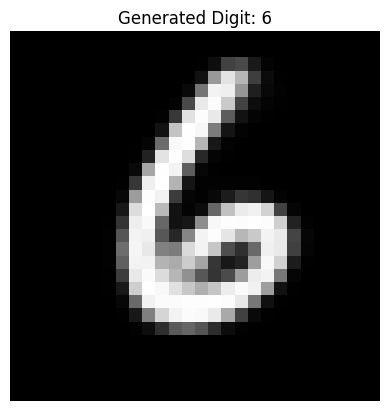

In [ ]:
# 9. Generate Handwritten Digit
def generate_digit(digit):
    z = digit_centers[digit]
    z = np.expand_dims(z, axis=0)

    generated = decoder.predict(z, verbose=0)

    plt.imshow(generated[0].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Generated Digit: {digit}")
    plt.show()

# Example
generate_digit(6)

Digit between 6 and 8 is: 7


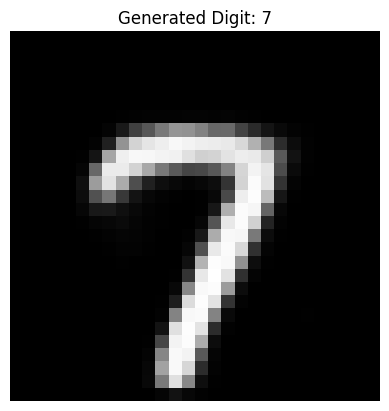

Digit between 4 and 6 is: 5


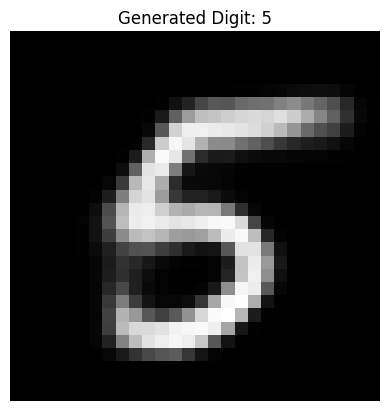

Digit between 7 and 9 is: 8


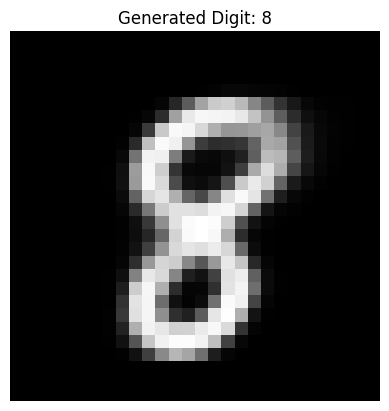

In [ ]:
# 10. Generate Digit Between Two Numbers
def generate_between_digits(a, b):
    middle_digit = round((a + b) / 2)

    print(f"Digit between {a} and {b} is: {middle_digit}")

    generate_digit(middle_digit)

# Examples
generate_between_digits(6, 8)
generate_between_digits(4, 6)
generate_between_digits(7, 9)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 144ms/step - loss: 0.2028 - val_loss: 0.1346
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - loss: 0.1295 - val_loss: 0.1240
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 143ms/step - loss: 0.1225 - val_loss: 0.1195
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - loss: 0.1187 - val_loss: 0.1168
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - loss: 0.1161 - val_loss: 0.1148
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 144ms/step - loss: 0.1141 - val_loss: 0.1130
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - loss: 0.1125 - val_loss: 0.1117
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - loss: 0.1112 - val_loss: 0.1108
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - loss: 0.1102 - val_loss: 0.1102
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 143ms/step - loss: 0.1092 - val_loss: 0.1092
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


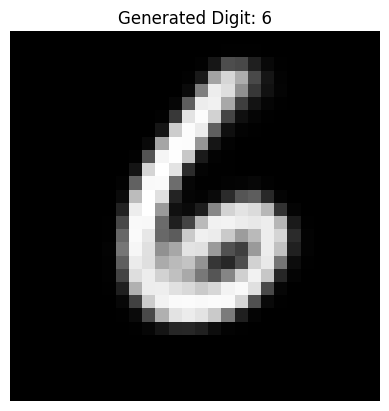

Digit between 6 and 8 is: 7


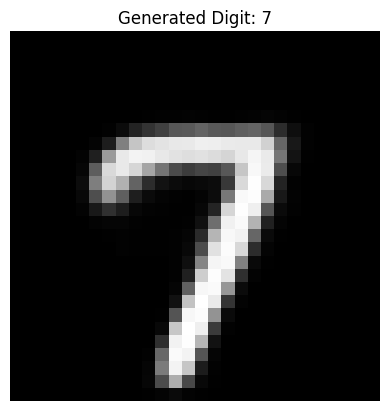

Digit between 4 and 6 is: 5


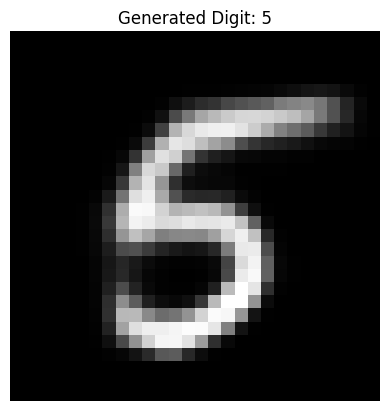

Digit between 7 and 9 is: 8


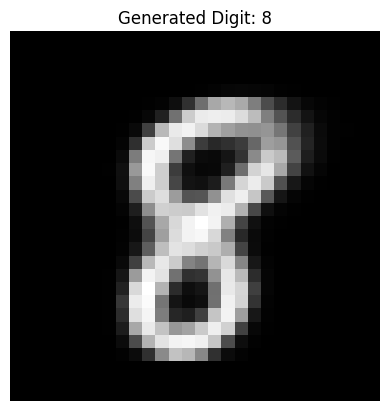

Models saved successfully


In [ ]:
# 11. Save Models
autoencoder.save("mnist_autoencoder.keras")
encoder.save("mnist_encoder.keras")
decoder.save("mnist_decoder.keras")

print("Models saved successfully")
